In [1]:
# !pip install roboflow

In [2]:
# from roboflow import Roboflow
# rf = Roboflow(api_key="p5A1Dc89ug39Uh25pdHW")
# project = rf.workspace("roboflow-58fyf").project("rock-paper-scissors-sxsw")
# version = project.version(14)
# dataset = version.download("darknet")

In [ ]:

from roboflow import Roboflow
rf = Roboflow(api_key="")
project = rf.workspace("roboflow-universe-projects").project("license-plate-recognition-rxg4e")
version = project.version(13)
dataset = version.download("darknet")

loading Roboflow workspace...
loading Roboflow project...


Extracting Dataset Version Zip to License-Plate-Recognition-13 in darknet:: 100%|██████████| 203740/203740 [00:36<00:00, 5639.54it/s]


In [3]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [4]:
import torch
print(torch.version.cuda)  # should be 13.x
print(torch.cuda.is_available())  # should be True
print(torch.cuda.current_device())
print(torch.cuda.get_device_name(torch.cuda.current_device()))

11.3
True
0
Tesla P100-PCIE-16GB


/usr/local/lib/python3.8/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import os

dataset_path = "./rock-paper-scissors-14"
for split in ["train", "valid"]:
    label_dir = os.path.join(dataset_path, split)
    for fname in os.listdir(label_dir):
        if not fname.endswith(".txt"):
            continue
        with open(os.path.join(label_dir, fname)) as f:
            for i, line in enumerate(f):
                parts = line.strip().split()
                if not parts:
                    continue
                cls = int(parts[0])
                if cls >= 3 or cls < 0:
                    print(f"BAD LABEL in {fname} line {i}: class={cls}")

In [6]:
from super_gradients.training.datasets import YoloDarknetFormatDetectionDataset

dataset_path = "./rock-paper-scissors-14"

train_dataset = YoloDarknetFormatDetectionDataset(
    data_dir=dataset_path,
    images_dir="train",
    labels_dir="train",
    classes=["Rock", "Paper", "Scissors"],
    show_all_warnings=True
)

val_dataset = YoloDarknetFormatDetectionDataset(
    data_dir=dataset_path,
    images_dir="valid",
    labels_dir="valid",
    classes=["Rock", "Paper", "Scissors"]
)

The console stream is logged into /root/sg_logs/console.log


[2026-03-06 07:49:46] INFO - crash_tips_setup.py - Crash tips is enabled. You can set your environment variable to CRASH_HANDLER=FALSE to disable it


[WARNING]No module named 'pycocotools'


[2026-03-06 07:49:49] INFO - env_sanity_check.py - Library check is not supported when super_gradients installed through "git+https://github.com/..." command
[2026-03-06 07:49:49] INFO - detection_dataset.py - Dataset Initialization in progress. `cache_annotations=True` causes the process to take longer due to full dataset indexing.
Indexing dataset annotations: 100%|██████████| 6455/6455 [00:00<00:00, 7097.60it/s]
[2026-03-06 07:49:50] INFO - detection_dataset.py - Dataset Initialization in progress. `cache_annotations=True` causes the process to take longer due to full dataset indexing.


Indexing dataset annotations: 100%|██████████| 576/576 [00:00<00:00, 7318.06it/s]


The dataset was returning each sample's labels as [x1, y1, x2, y2, class], but YOLOX loss expects targets in [batch_idx, class, cx, cy, w, h] format. Three things were wrong:

Class was in the last column — we were accidentally reading x1 as the class, which gave huge values like 305, 268 etc. that were way out of range for F.one_hot(..., num_classes=3), triggering the CUDA assert.
No batch index — the loss needs to know which image each box belongs to since all boxes across the batch are concatenated into one tensor. We prepended i (the loop index) for each sample.
Corner format → center format — the dataset gave [x1, y1, x2, y2] (top-left/bottom-right corners) but YOLOX expects [cx, cy, w, h] (center + dimensions), so we converted them.

In [7]:
from torch.utils.data import DataLoader
from super_gradients.training.utils.collate_fn import DetectionCollateFN
import numpy as np
import torch
def yolox_collate_fn(batch):
    imgs, targets = zip(*batch)
    imgs = torch.stack([torch.from_numpy(np.array(img)).permute(2, 0, 1).float() for img in imgs], 0)
    padded_targets = []
    for i, t in enumerate(targets):
        t = torch.as_tensor(t, dtype=torch.float32)
        if t.shape[0] > 0:
            # Dataset gives [x1, y1, x2, y2, class] — class is index 4 (5-col, no batch idx yet)
            cls = t[:, 4:5]                          # class is last column
            x1, y1, x2, y2 = t[:, 0], t[:, 1], t[:, 2], t[:, 3]
            cx = ((x1 + x2) / 2).unsqueeze(1)
            cy = ((y1 + y2) / 2).unsqueeze(1)
            w  = (x2 - x1).unsqueeze(1)
            h  = (y2 - y1).unsqueeze(1)
            batch_col = torch.full((t.shape[0], 1), i, dtype=torch.float32)
            # Final: [batch_idx, class, cx, cy, w, h]
            padded_targets.append(torch.cat([batch_col, cls, cx, cy, w, h], dim=1))
    targets = torch.cat(padded_targets, 0) if padded_targets else torch.zeros((0, 6))
    return imgs, targets
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=yolox_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=yolox_collate_fn)

In [8]:
from super_gradients.training import models
from super_gradients.training import Trainer
import torch
from torch.utils.data import DataLoader
from super_gradients.common.object_names import Models

trainer = Trainer(experiment_name="yolon", ckpt_root_dir="./checkpoints")

model = models.get(
    Models.YOLOX_N,
    num_classes=3,
    checkpoint_path="/app/models/yolox_nano.pth",
    strict_load=False
)
model.num_classes

/usr/local/lib/python3.8/dist-packages/super_gradients/common/deprecate.py:279: DeprecationWarning: Parameter `arch_params.channels_in` is deprecated since version `3.3.0` and will be removed in version `4.0.0`.
Please update your code to use the `arch_params.in_channels` instead of `arch_params.channels_in`.
  warnings.warn(message, DeprecationWarning)
[2026-03-06 07:49:50] INFO - checkpoint_utils.py - Successfully loaded model weights from /app/models/yolox_nano.pth checkpoint.


3

In [9]:
from super_gradients.training import training_hyperparams
train_params = training_hyperparams.get('coco2017_yolox')

train_params['max_epochs'] = 30
train_params['lr_warmup_epochs'] = 0
train_params['lr_cooldown_epochs'] = 0
train_params['criterion_params']['num_classes'] = 3
train_params['average_best_models'] = False
train_params['initial_lr'] = 0.0005
train_params['cosine_final_lr_ratio'] = 0.9
train_params['mixed_precision'] = False

In [10]:
train_params['max_epochs'] = 80
train_params['initial_lr'] = 0.001
train_params['cosine_final_lr_ratio'] = 0.05
train_params['lr_warmup_epochs'] = 3
train_params['lr_cooldown_epochs'] = 10
train_params['criterion_params']['num_classes'] = 3
train_params['average_best_models'] = True
train_params['mixed_precision'] = True
train_params['ema'] = True
train_params['sync_bn'] = False

In [ ]:
trainer.train(model=model, training_params=train_params, train_loader=train_loader, valid_loader=val_loader)

[2026-03-06 07:49:51] WARNING - sg_trainer.py - Train dataset size % batch_size != 0 and drop_last=False, this might result in smaller last batch.
[2026-03-06 07:49:54] INFO - sg_trainer.py - Starting a new run with `run_id=RUN_20260306_074954_917040`
[2026-03-06 07:49:54] INFO - sg_trainer.py - Checkpoints directory: ./checkpoints/yolon/RUN_20260306_074954_917040
[2026-03-06 07:49:54] INFO - sg_trainer.py - Using EMA with params {'decay': 0.9999, 'decay_type': 'exp', 'beta': 15}
/usr/local/lib/python3.8/dist-packages/super_gradients/training/utils/optimizer_utils.py:108: DeprecationWarning: initialize_param_groups and update_param_groups usages are deprecated since 3.4.0, will be removed in 3.5.0 and have no effect. 
 Assign different learning rates by passing a mapping of layer name prefixes to lr values through initial_lr training hyperparameter (i.e initial_lr={'backbone': 0.01, 'default':0.1})
  warnings.warn(


The console stream is now moved to ./checkpoints/yolon/RUN_20260306_074954_917040/console_Mar06_07_49_54.txt


[2026-03-06 07:49:55] INFO - sg_trainer_utils.py - TRAINING PARAMETERS:
    - Mode:                         Single GPU
    - Number of GPUs:               1          (1 available on the machine)
    - Full dataset size:            3939       (len(train_set))
    - Batch size per GPU:           32         (batch_size)
    - Batch Accumulate:             1          (batch_accumulate)
    - Total batch size:             32         (num_gpus * batch_size)
    - Effective Batch size:         32         (num_gpus * batch_size * batch_accumulate)
    - Iterations per epoch:         124        (len(train_loader))
    - Gradient updates per epoch:   124        (len(train_loader) / batch_accumulate)
    - Model: YoloX_N  (897.14K parameters, 897.14K optimized)
    - Learning Rates and Weight Decays:
      - default: (897.14K parameters). LR: 0.001 (897.14K parameters) WD: 0.0, (15.42K parameters), WD: 0.0005, (881.73K parameters)

[2026-03-06 07:49:55] INFO - sg_trainer.py - Started training for

SUMMARY OF EPOCH 0
├── Train
│   ├── Yoloxdetectionloss/iou = 0.938
│   ├── Yoloxdetectionloss/obj = 21.4579
│   ├── Yoloxdetectionloss/cls = 0.7932
│   ├── Yoloxdetectionloss/l1 = 0.0
│   ├── Yoloxdetectionloss/num_fg = 1.2368
│   └── Yoloxdetectionloss/loss = 26.9412
└── Validation
    ├── Yoloxdetectionloss/iou = 0.998
    ├── Yoloxdetectionloss/obj = 9.3799
    ├── Yoloxdetectionloss/cls = 0.1529
    ├── Yoloxdetectionloss/l1 = 0.0
    ├── Yoloxdetectionloss/num_fg = 1.0025
    ├── Yoloxdetectionloss/loss = 14.5228
    ├── Precision@0.50:0.95 = 0.0
    ├── Recall@0.50:0.95 = 0.0
    ├── Map@0.50:0.95 = 0.0
    ├── F1@0.50:0.95 = 0.0
    └── Best_score_threshold = 0.0



Validating epoch 1: 100%|██████████| 11/11 [00:05<00:00,  2.12it/s]
[2026-03-06 07:53:08] INFO - base_sg_logger.py - Checkpoint saved in ./checkpoints/yolon/RUN_20260306_074954_917040/ckpt_best.pth
[2026-03-06 07:53:08] INFO - sg_trainer.py - Best checkpoint overriden: validation mAP@0.50:0.95: 0.00019978162890765816


...

SUMMARY OF EPOCH 78
├── Train
│   ├── Yoloxdetectionloss/iou = 0.2981
│   │   ├── Epoch N-1      = 0.2986 (↘ -0.0005)
│   │   └── Best until now = 0.2986 (↘ -0.0005)
│   ├── Yoloxdetectionloss/obj = 0.4824
│   │   ├── Epoch N-1      = 0.486  (↘ -0.0037)
│   │   └── Best until now = 0.486  (↘ -0.0037)
│   ├── Yoloxdetectionloss/cls = 0.4885
│   │   ├── Epoch N-1      = 0.489  (↘ -0.0005)
│   │   └── Best until now = 0.489  (↘ -0.0005)
│   ├── Yoloxdetectionloss/l1 = 0.0
│   │   ├── Epoch N-1      = 0.0    (= 0.0)
│   │   └── Best until now = 0.0    (= 0.0)
│   ├── Yoloxdetectionloss/num_fg = 7.746
│   │   ├── Epoch N-1      = 7.7432 (↗ 0.0028)
│   │   └── Best until now = 1.2368 (↗ 6.5093)
│   └── Yoloxdetectionloss/loss = 2.4612
│       ├── Epoch N-1      = 2.4679 (↘ -0.0067)
│       └── Best until now = 2.4679 (↘ -0.0067)
└── Validation
    ├── Yoloxdetectionloss/iou = 0.3986
    │   ├── Epoch N-1      = 0.3983 (↗ 0.0003)
    │   └── Best until now = 0.3983 (↗ 0.0003)
    ├── Yoloxdet

Validating epoch 79: 100%|██████████| 11/11 [00:05<00:00,  2.09it/s]


SUMMARY OF EPOCH 79
├── Train
│   ├── Yoloxdetectionloss/iou = 0.3009
│   │   ├── Epoch N-1      = 0.2981 (↗ 0.0029)
│   │   └── Best until now = 0.2981 (↗ 0.0029)
│   ├── Yoloxdetectionloss/obj = 0.4813
│   │   ├── Epoch N-1      = 0.4824 (↘ -0.0011)
│   │   └── Best until now = 0.4824 (↘ -0.0011)
│   ├── Yoloxdetectionloss/cls = 0.4945
│   │   ├── Epoch N-1      = 0.4885 (↗ 0.006)
│   │   └── Best until now = 0.4885 (↗ 0.006)
│   ├── Yoloxdetectionloss/l1 = 0.0
│   │   ├── Epoch N-1      = 0.0    (= 0.0)
│   │   └── Best until now = 0.0    (= 0.0)
│   ├── Yoloxdetectionloss/num_fg = 7.7355
│   │   ├── Epoch N-1      = 7.746  (↘ -0.0105)
│   │   └── Best until now = 1.2368 (↗ 6.4988)
│   └── Yoloxdetectionloss/loss = 2.4804
│       ├── Epoch N-1      = 2.4612 (↗ 0.0192)
│       └── Best until now = 2.4612 (↗ 0.0192)
└── Validation
    ├── Yoloxdetectionloss/iou = 0.3983
    │   ├── Epoch N-1      = 0.3986 (↘ -0.0002)
    │   └── Best until now = 0.3983 (↗ 1e-04)
    ├── Yoloxdetection

[2026-03-06 09:58:52] INFO - sg_trainer.py - RUNNING ADDITIONAL TEST ON THE AVERAGED MODEL...
Validating epoch 80:  91%|█████████ | 10/11 [00:04<00:00,  2.03it/s]

Validating epoch 80: 100%|██████████| 11/11 [00:05<00:00,  2.08it/s]
[2026-03-06 09:58:57] INFO - base_sg_logger.py - [CLEANUP] - Successfully stopped system monitoring process


[2026-03-06 09:58:58] INFO - pipelines.py - Fusing some of the model's layers. If this takes too much memory, you can deactivate it by setting `fuse_model=False`
/usr/local/lib/python3.8/dist-packages/super_gradients/training/utils/visualization/utils.py:67: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("gist_rainbow", num_classes)


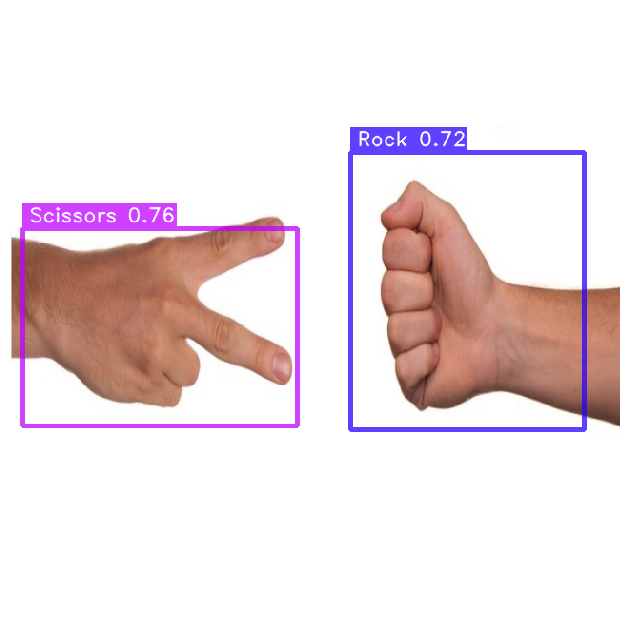

In [12]:
import cv2
import requests
import numpy as np
url = 'https://www.asianscientist.com/wp-content/uploads/bfi_thumb/20170815-rock-scissors-pixabay-34f3h8kx0ucail5dbcp8n4.jpg'
# url='https://bathroomreader.com/wp-content/uploads/2017/11/Rock-Paper-Scissors-1.jpg'
img_array = np.asarray(bytearray(requests.get(url).content), dtype=np.uint8)
img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (640, 640))  # must be multiple of 32

prediction = model.predict(img, conf=0.7)
prediction.show()

In [ ]:
export_result = model.export(
    output="../models/yolox_n_rps.onnx",
    input_image_shape=(640, 640),
    onnx_export_kwargs={"opset_version": 11}
)

print(export_result)

Model exported successfully to ../models/yolox_n_rps.onnx
Model expects input image of shape [1, 3, 640, 640]
Input image dtype is torch.uint8
Exported model already contains preprocessing (normalization) step, so you don't need to do it manually.
Preprocessing steps to be applied to input image are:
Sequential(
  (0): CastTensorTo(dtype=torch.float32)
  (1): ChannelSelect(channels_indexes=tensor([2, 1, 0], device='cuda:0'))
)

Exported model contains postprocessing (NMS) step with the following parameters:
    num_pre_nms_predictions=1000
    max_predictions_per_image=1000
    nms_threshold=0.65
    confidence_threshold=0.5
    output_predictions_format=batch

Exported model is in ONNX format and can be used with ONNXRuntime
To run inference with ONNXRuntime, please use the following code snippet:

    import onnxruntime
    import numpy as np
    session = onnxruntime.InferenceSession("../models/yolox_n_rps.onnx", providers=["CUDAExecutionProvider", "CPUExecutionProvider"])
    input